In [1]:
from datetime import date
import time

import warnings
warnings.filterwarnings(action='once')


from fidelity import *
from povm import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
%matplotlib inline


today = date.today()
datestr = today.strftime("%y%m%d")


# Hyperparameters
Nq = 6
split = 0.8
# Nf = int(sys.argv[3])

povm = POVM('pauli6')
Na = povm.Na

In [2]:
# GHZ state density matrix
Ne = 4
rhoKB = np.zeros((Ne, 2*Nq), dtype=int)
rhoAmp = np.zeros((Ne), dtype=complex)

rhoKB[1, :] = 1
rhoKB[2, :Nq] = 1
rhoKB[3, Nq:] = 1

rhoAmp[0] = 0.5
rhoAmp[1] = 0.5
rhoAmp[2] = 0.5
rhoAmp[3] = np.conj(rhoAmp[2])


density = {}
density['KB'] = rhoKB
density['Amp'] = rhoAmp


ghz = SampleDM(Nq, povm, density)


# Generate Probability table

In [3]:
from ann import *

Ns = 40000

for Ns in [40000]:
    model = torch.load(f='mod/aqt-ghz-large-600_2-64-4_6-%i.mod'%Ns)

    t = time.time()
    pt_model = POVMProbTable(model)

    np.save('data/aqt-ghz-large-600_2-64-4_6-%i_pt.npy'%Ns, pt_model)
    print('%f seconds'%(time.time()-t))

160.178256 seconds


# Error scaling

In [7]:
pt_ghz = POVMProbTable(ghz)

In [12]:
Ns_list = np.array([40000, 80000, 130000, 200000, 400000])

pt_model = np.zeros((len(Ns_list), len(pt_ghz)))
pt_data = np.zeros((len(Ns_list), len(pt_ghz)))

for i in range(len(Ns_list)):
    Ns = Ns_list[i]
    
    pt_model[i] = np.load('data/aqt-ghz-large-400_2-64-4_6-%i_pt.npy'%Ns)

    data = np.load('data/ghz-sim-Pauli6-Nq6-Ns%i.npy'%Ns)

    for d in data:
        pt_data[i, basestr2int(d, Na)] += 1/len(data)


In [11]:
print(sum(pt_ghz))
print([sum(a) for a in pt_model])
print([sum(a) for a in pt_data])

0.9999999999997934
[0.9999965406808137, 0.9999987032674832, 0.9999975346468266, 0.9999974087503123, 0.9999999153293616]
[1.0000000000002296, 1.0000000000001676, 1.0000000000000282, 1.0000000000000286, 1.000000000000022]


In [13]:
sd_model = np.zeros((Ns_list.shape))
sd_data = np.zeros((Ns_list.shape))

for i in range(len(Ns_list)):
    sd_model[i] = np.sqrt(np.mean((pt_ghz-pt_model[i])**2))
    sd_data[i] = np.sqrt(np.mean((pt_ghz-pt_data[i])**2))

In [45]:
print(sd_data)
print(sd_model)

[2.31271058e-05 1.62340819e-05 1.29398586e-05 1.03590042e-05
 7.37763182e-06]
[7.91190573e-06 7.32833451e-06 5.90062202e-06 3.98212593e-06
 3.36154706e-06]


[-0.49534174 -5.42861318]
[-0.41104711 -7.29843114]


/home/peter/.local/lib/python3.6/site-packages/ipykernel_launcher.py:37: MatplotlibDeprecationWarning: 
The frameon kwarg was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use facecolor instead.


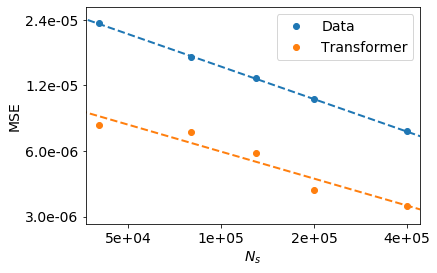

In [52]:
fig, ax = plt.subplots()





p_data = np.polyfit(np.log(Ns_list), np.log(sd_data), deg=1)
p_model = np.polyfit(np.log(Ns_list), np.log(sd_model), deg=1)

fx = np.array([10, 15])
ax.plot(fx, np.polyval(p_data, fx), linestyle='--', color='tab:blue', linewidth=2)
ax.plot(fx, np.polyval(p_model, fx), linestyle='--', color='tab:orange', linewidth=2)

ax.plot(np.log(Ns_list), np.log(sd_data), marker='.', markersize=12, linestyle='', color='tab:blue', label='Data')
ax.plot(np.log(Ns_list), np.log(sd_model), marker='.', markersize=12, linestyle='', color='tab:orange', label='Transformer')



xticks = np.array([50000, 100000, 200000, 400000])
ax.set_xticks(np.log(xticks))
ax.set_xticklabels(['%.e'%x for x in xticks], size=14)
ax.set_xlabel('$N_s$', size=14)

yticks = np.array([3e-6, 6e-6, 1.2e-5, 2.4e-5])
ax.set_yticks(np.log(yticks))
ax.set_yticklabels(['%.1e'%y for y in yticks], size=14)
ax.set_ylabel('MSE', size=14)

ax.set_xbound(10.5, 13)
ax.set_ybound(-12.8, -10.5)
ax.legend(fontsize=14)


print(p_data)
print(p_model)

fig.savefig('figures/povm_error_scaling.pdf', dpi=300, frameon=True,bbox_inches="tight")

# Histogram

In [7]:
pt_ghz = POVMProbTable(ghz)

In [11]:
Ns = 40000

pt_model = np.load('data/aqt-ghz-large-600_2-64-4_6-%i_pt.npy'%Ns)

data = np.load('data/ghz-sim-Pauli6-Nq6-Ns%i.npy'%Ns)

pt_data = np.zeros(pt_model.shape)

for d in data:
    pt_data[basestr2int(d, Na)] += 1/len(data)

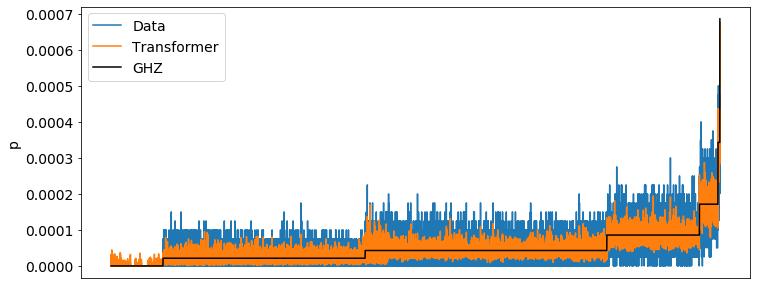

In [12]:
ghz_as = np.argsort(pt_ghz)

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(start=1, stop=len(pt_ghz)+1)**3

ax.plot(x, pt_data[ghz_as], label='Data')
ax.plot(x, pt_model[ghz_as], label='Transformer')
ax.plot(x, pt_ghz[ghz_as], label='GHZ', color='black')

# axins = inset_axes(ax,6,2,bbox_to_anchor=(-0.06,-0.02, 1,1),bbox_transform=ax.transAxes)
# ghz_as_pos = (pt_ghz[ghz_as] > 0)

# axins.plot(pt_data[ghz_as][ghz_as_pos])
# axins.plot(pt_model[ghz_as][ghz_as_pos])
# axins.plot(pt_ghz[ghz_as][ghz_as_pos], color='black')
# axins.set_xticks([])

ax.set_xticks([])
ax.set_ylabel('p', size=14)
ax.tick_params(axis='y', labelsize=14)

ax.legend(fontsize=14)
# fig.savefig('figures/povm_sorted_%i.pdf'%Ns, dpi=300, frameon=True,bbox_inches="tight")

/home/peter/.local/lib/python3.6/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in log
  app.launch_new_instance()


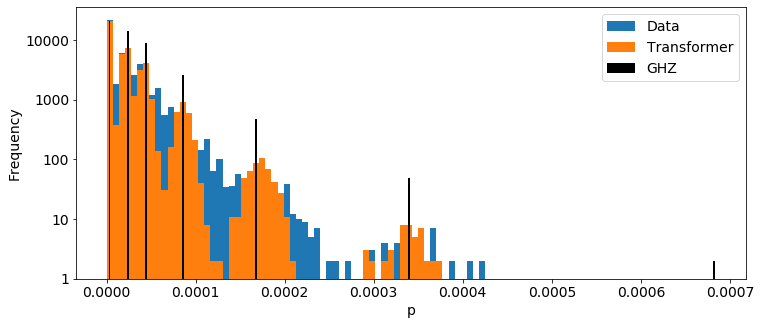

In [9]:

Nbin = 100

xbin, dx = np.linspace(start=min(pt_ghz), stop=max(pt_ghz), num=Nbin+1, retstep=True)

x = (xbin[:-1]+xbin[1:])/2

h_ghz, _ = np.histogram(pt_ghz, bins=xbin)
h_data, _ = np.histogram(pt_data, bins=xbin)
h_model, _ = np.histogram(pt_model, bins=xbin)

fig, ax = plt.subplots(figsize=(12,5))




ax.bar(x, np.log(h_data), width=dx, label='Data')
ax.bar(x, np.log(h_model), width=dx, label='Transformer')
ax.bar(x, np.log(h_ghz), width=0.3*dx, label='GHZ', color='black')

yticks = [1, 10, 100, 1000, 10000]
ax.set_yticks(np.log(yticks))
ax.set_yticklabels(['%i'%i for i in yticks])
ax.set_ylabel('Frequency', size=14)
ax.set_xlabel('p', size=14)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14)

# fig.savefig('figures/povm_histogram.pdf', dpi=300, frameon=True,bbox_inches="tight")